In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':50,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-6),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}
"""
pt_parameters = {'tmax':5,
                 'steps':50, 
                 'dkmax':100,
                 'epsrel':10**(-4),
                 'alpha':1e-20,
                 'omega_cutoff':3.04,                 
                 'temp':0.131}"""



omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

initial_state = op.spin_dm('x+')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

t_list = np.linspace(0,t_max,num_steps+1)


In [2]:
import tensornetwork as tn
d = 2  # dimension of each leg
start_cap = np.zeros((d, d, d))
for i in range(d):
    start_cap[i, i, i] = 1.0

x=tn.Node(start_cap)
print(x.tensor.shape)


(2, 2, 2)


In [3]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
import numpy as np
import matplotlib.pyplot as plt

#1
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)

pt=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_tebd = pt.get_process_tensor()

building influence functional:  38%|███▊      | 19/50 [00:00<00:00, 186.63it/s]

building influence functional: 100%|██████████| 50/50 [00:01<00:00, 38.83it/s] 

rank  142 (142, 4, 142)


--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:05
Elapsed time: 5.5s


array([[ 0.4999885 -1.36099943e-14j, -0.48245057+1.60778787e-14j],
       [-0.48245057+1.02246146e-14j,  0.4999885 -1.63334563e-14j]])

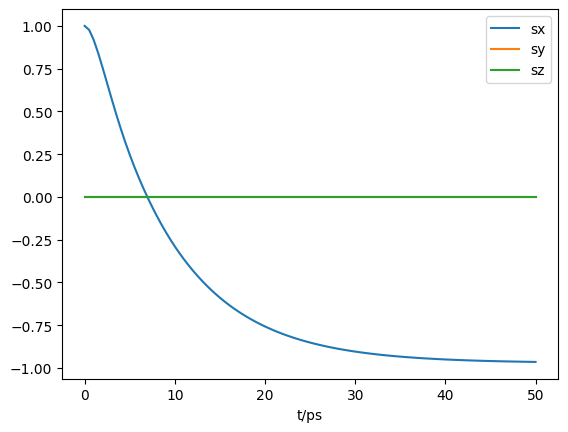

In [4]:
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')/2

system_td = oqupy.TimeDependentSystem(hamiltonian_t)


Rho_0=oqupy.operators.spin_dm('x+')
#Rho_0=oqupy.operators.spin_dm('z-')

dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_tebd,        
       system=system_td,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

t, s_x = dynamics.expectations(op.sigma('x'), real=True)
t,s_z = dynamics.expectations(op.sigma('z'), real=True)
t, s_y = dynamics.expectations(op.sigma('y'), real=True)

plt.plot(t,s_x,label='sx')
plt.plot(t,s_y,label='sy')
plt.plot(t,s_z,label='sz')
plt.xlabel('t/ps')
plt.legend()
dynamics.states[-1]


In [5]:
from oqupy.gate_gradient import compute_dynamical_map,compute_dynamical_map_and_grad
from oqupy.gradient import state_gradient

def discrete_hamiltonian(hx,hz):
    return hx*op.sigma('x')/2 + hz*op.sigma('z')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_z = np.ones(2*num_steps)*0
h_x = np.ones(2*num_steps)*omega_cutoff

parameters = np.vstack((h_x,h_z)).T
parameters.shape

gradient=state_gradient(system=system,
                        initial_state=initial_state,
                        target_derivative=op.spin_dm('x-').T,
                        process_tensors=[process_tensor_tebd],
                        parameters=parameters,
                        num_steps=num_steps)



--> Compute forward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.7s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.1s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:10
Elapsed time: 10.7s


In [6]:
map_list,grad_list=compute_dynamical_map_and_grad(system,
        [process_tensor_tebd],
        parameters,
        dt,
        start_time=0,
        num_steps=num_steps)

In [9]:
import numpy as npt
from scipy.optimize import approx_fprime

def func_jacobian(maps_list, func, eps=1e-8):
    """
    maps_list: list of 4x4 numpy arrays
    func: callable taking a list of 4x4 numpy arrays and returning scalar
    eps: finite difference step
    Returns:
        derivatives: list of 4x4 numpy arrays, df/dM_t for each timestep
    """
    derivatives = []
    
    for t, M in enumerate(maps_list):
        # flatten the matrix
        M_flat = M.flatten()
        
        # define a wrapper function that takes flattened M
        def f_flat(Mf):
            Mf_matrix = Mf.reshape(M.shape)
            maps_copy = maps_list.copy()
            maps_copy[t] = Mf_matrix
            return func(maps_copy)
        
        grad_flat = approx_fprime(M_flat, f_flat, epsilon=eps)
        grad_matrix = grad_flat.reshape(M.shape)
        derivatives.append(grad_matrix)
    
    return derivatives

def trace_distance_grad_maps(maps_list, target):
    grad_list = []
    for M in maps_list:
        X = M - target
        U, S, Vh = np.linalg.svd(X)
        grad = 0.5 * U @ Vh  # derivative w.r.t M
        grad_list.append(grad)
    return grad_list


In [10]:
def superop_to_choi(map):
    d=2

    choi_matrix=np.zeros((d*d,d*d),dtype=complex)

    for i in range(d):
        for j in range(d):
            e_ij=np.zeros((d,d),dtype=complex)
            e_ij[i,j]=1.0

            phi_e_ij= map @ e_ij.flatten(order='C')
            phi_e_ij_mat = phi_e_ij.reshape((d,d), order='C')
            choi_matrix+=np.kron(e_ij,phi_e_ij_mat)
    
    return choi_matrix


In [11]:
def choi_to_kraus(choi):
    vals,vecs=np.linalg.eigh(choi)
    kraus_ops=[]

    for val,vec in zip(vals,vecs.T):
        if val>1e-20:
            K=np.sqrt(val)*vec.reshape((2,2),order='C')
            kraus_ops.append(K)
    return kraus_ops

In [12]:

def rotation_fidelity(unitary,kraus_ops):
    d=2
    first_term=np.zeros((d,d),dtype=complex)
    second_term=0
    for kraus in kraus_ops:
        M=unitary.conj().T @ kraus

        first_term+=M.conj().T @ M
        second_term+=np.abs(np.trace(M))**2

    first_term=np.trace(first_term)

    fidelity=(first_term+second_term)/(d*(d+1))
    return fidelity

target_unitary = np.array(-1j*op.sigma("x")/2, dtype=complex)  # pi rotation around x-axis

kraus_ops=choi_to_kraus(superop_to_choi(map_list[-1]))

rotation_fidelity(target_unitary,kraus_ops)


(0.12078025841550447+0j)

In [13]:
import numpy as np
from scipy.optimize import approx_fprime

def rotation_fidelity_superop(unitary, superop):
    """
    Compute the rotation fidelity given a superoperator (acts on vectorized density matrices).
    """
    # Convert superoperator to Choi, then to Kraus for fidelity computation
    kraus_ops = choi_to_kraus(superop_to_choi(superop))
    return rotation_fidelity(unitary, kraus_ops).real

def superop_to_real_vector(superop):
    """complex superoperator to a real vector (real + imag parts)."""
    return np.concatenate([superop.real.flatten(), superop.imag.flatten()])

def real_vector_to_superop(vec, dim):
    """real vector back to complex superoperator."""
    n = dim**2
    real_part = vec[:n*n].reshape((n,n))
    imag_part = vec[n*n:].reshape((n,n))
    return real_part + 1j*imag_part

def fidelity_wrapper(vec, unitary, dim):
    superop = real_vector_to_superop(vec, dim)
    return rotation_fidelity_superop(unitary, superop)


dim = 2  # qubit
map_superop = map_list[-1]  # a single superoperator from your list
unitary = target_unitary    

x0 = superop_to_real_vector(map_superop)
epsilon = 1e-8

grad_real = approx_fprime(x0, fidelity_wrapper, epsilon, unitary, dim)
t
# Convert gradient back to complex matrix form (same shape as superoperator)
grad_superop = real_vector_to_superop(grad_real, dim)

def fidelity_map_deriv(map,unitary):

    x0 = superop_to_real_vector(map)
    
    grad_real = approx_fprime(x0, fidelity_wrapper, epsilon, unitary, dim)

    # Convert gradient back to complex matrix form (same shape as superoperator)
    grad_superop = real_vector_to_superop(grad_real, dim)

    return grad_superop


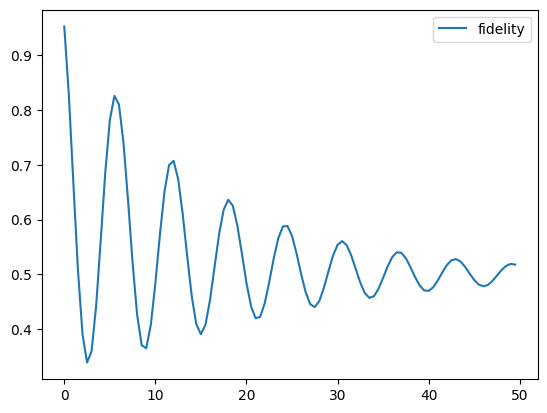

3.3885831712133685e-05


In [14]:
import scipy as sp

fidelitys=[]
trace_distance=[]
for i,map in enumerate(map_list):

    choi_matrix=superop_to_choi(map)
    kraus_ops=choi_to_kraus(choi_matrix)

    #target_unitary = np.array(1j*op.sigma("x"), dtype=complex)  # pi rotation around x-axis
    #target_unitary = sp.linalg.expm(-1j*omega_cutoff*(i+1)*dt*op.sigma('x')/2)
    target_unitary=np.identity(2)

    fidelitys.append(rotation_fidelity(target_unitary,kraus_ops).real)


plt.plot(t[:-1],fidelitys,label='fidelity')
#plt.plot(t[:-1],trace_distance)
plt.legend()
plt.show()
I = np.eye(2)
residual = np.sum([K.conj().T @ K for K in kraus_ops], axis=0) - I
print(np.linalg.norm(residual))

(200, 4, 4)


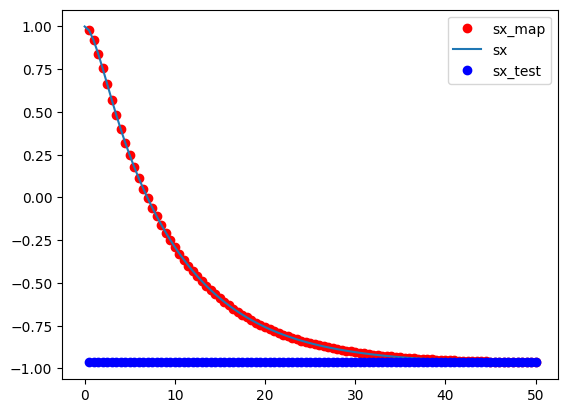

In [15]:
sx_map=[]
sy_map=[]
sz_map=[]

sx_test=[]
test_map=dyn_map_derivatives[:,0,:,:]

print(test_map.shape)
for i,map in enumerate(map_list):
    vec_Rho=Rho_0.flatten('C')
    final_Rho=vec_Rho.T@map
    test_Rho=vec_Rho.T@test_map[2*i,:,:]

    #final_Rho_a=vec_Rho.T@superoperator
    # Reshape the final state back to a density matrix
    final_Rho = final_Rho.reshape((2, 2), order='C')
    sx_map.append(np.trace(final_Rho@op.sigma('x')).real)
    sy_map.append(np.trace(final_Rho@op.sigma('y')).real)
    sz_map.append(np.trace(final_Rho@op.sigma('z')).real)

    test_Rho = test_Rho.reshape((2, 2), order='C')
    sx_test.append(np.trace(test_Rho@op.sigma('x')).real)


plt.plot(t[1:],sx_map,'ro',label='sx_map')
plt.plot(t,s_x,label='sx')
plt.plot(t[1:],sx_test,'bo',label='sx_test')
plt.legend()
plt.show()

In [ ]:
def map_and_grad(system,process_tensor_tebd,parameters,dt,num_steps):
        map_list,grad_list=compute_dynamical_map_and_grad(system,
                [process_tensor_tebd],
                parameters,
                dt,
                start_time=0,
                num_steps=num_steps)

        num_parameters = parameters.shape[1]

        propagators=system.get_propagators(dt,parameters)
        prop_derivs=system.get_propagator_derivatives(dt,parameters)

        dyn_map_derivatives=gate_chain_rule(adjoint_tensor=grad_list,propagators=propagators,dprop_dparam=prop_derivs,num_steps=num_steps,num_parameters=num_parameters)

        return map_list,dyn_map_derivatives

In [20]:
map_list,dyn_map_derivs=map_and_grad(system,process_tensor_tebd,parameters,dt,num_steps)

plt.plot(dyn_map_derivatives)

--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:11
Elapsed time: 11.8s


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


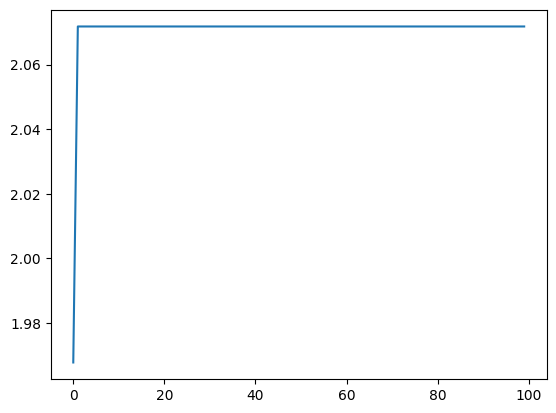

In [23]:
fidelity=rotation_fidelity(target_unitary,kraus_ops).real

fidelity_grads=[]
for map in map_list:
    fidelity_grads.append(fidelity_map_deriv(map,target_unitary))

map_grads=dyn_map_derivatives
# Adding adjacent elements
for i in range(0,map_grads.shape[0],2): 
    map_grads[i,:]=map_grads[i,:]+ map_grads[i+1,:]
        
map_grads=map_grads[0::2]

grads = np.sum(map_grads.sum(axis=1) * fidelity_grads, axis=(1,2))
plt.plot(grads)

In [ ]:

import scipy as sp
def infidandgrad(paras):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_parameters))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    maps,map_grads=map_and_grad(system,process_tensor_tebd,reshapedparas,dt,num_steps)

    # Adding adjacent elements
    for i in range(0,map_grads.shape[0],2): 
        map_grads[i,:]=map_grads[i,:]+ map_grads[i+1,:]
            
    map_grads=map_grads[0::2]
    
    choi_matrix=superop_to_choi(maps[-1])
    kraus_ops=choi_to_kraus(choi_matrix)

    #target_unitary = np.array(1j*op.sigma("x"), dtype=complex)  # pi rotation around x-axis
    #target_unitary = sp.linalg.expm(-1j*omega_cutoff*((num_steps-1)+1)*dt*op.sigma('x')/2)
    target_unitary=np.identity(2)
    # target unitary is rotation around x from t=0 to t=t_final

    fidelity=rotation_fidelity(target_unitary,kraus_ops).real

    fidelity_grads=[]
    for map in maps:
        fidelity_grads.append(fidelity_map_deriv(map,target_unitary))

    # Sum over the second axis of map_grads to match fidelity_grads shape
    grads = np.sum(map_grads.sum(axis=1) * fidelity_grads, axis=(1,2))
   # grads=np.sum(map_grads*fidelity_grads)

    grad_norm = np.linalg.norm(grads, ord=np.inf)  # same criterion L-BFGS-B uses

    print(f"Infidelity = {1-fidelity:.6f}, ||grad|| = {grad_norm:.6f}")


    # Return the minus the gradient as infidelity is being minimized 
    return 1-fidelity.real,(-1.0*grads.reshape((-1)).real).tolist()

In [19]:
# Set upper and lower bounds on control parameters
x_bound = [-5*np.pi,5*np.pi]
z_bound = [-np.pi,np.pi]
num_params=2
bounds = np.zeros((num_steps*num_params,2))

for i in range(0, num_params*num_steps,num_params):
        bounds[i] = x_bound
        bounds[i+1] = z_bound

z0 = np.zeros(num_steps)
x0 = np.ones(num_steps)*omega_cutoff

# Flatten list for input to optimizer
parameter_list=[item for pair in zip(x0, z0) for item in pair]

optimization_result = minimize(
                        fun=infidandgrad,
                        x0=parameter_list,
                        method='L-BFGS-B',
                        jac=True,
                        bounds=bounds,
                        options = {'disp':True, 'gtol': 1e-05}

                        
)

print("The maximal fidelity was found to be : ",1-optimization_result.fun)

--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:13
Elapsed time: 13.1s
Infidelity = 0.482058, ||grad|| = 0.009364
--> Apply chain rule:


IndexError: list index out of range

  0.0%    0 of  100 [----------------------------------------] 00:00:01

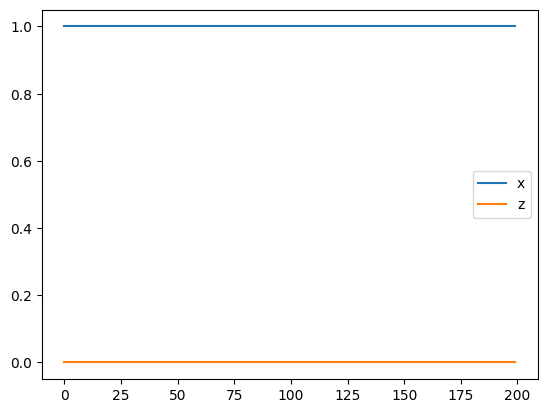

In [ ]:
optimized_params = optimization_result.x
reshapedparas=np.array([i for i in (optimized_params.reshape((-1,num_params))).tolist() for j in range(2)])

plt.plot(reshapedparas[:,0],label='x')
plt.plot(reshapedparas[:,1],label='z')
plt.legend()
plt.show()

--> Compute forward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 1.0s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.1s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:06
Elapsed time: 6.8s
--> Compute forward propagation:
 30.0%   30 of  100 [############----------------------------] 00:00:00

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.8s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:06
Elapsed time: 6.3s
--> Compute forward propagation:
 23.0%   23 of  100 [#########-------------------------------] 00:00:00

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:06
Elapsed time: 6.3s


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


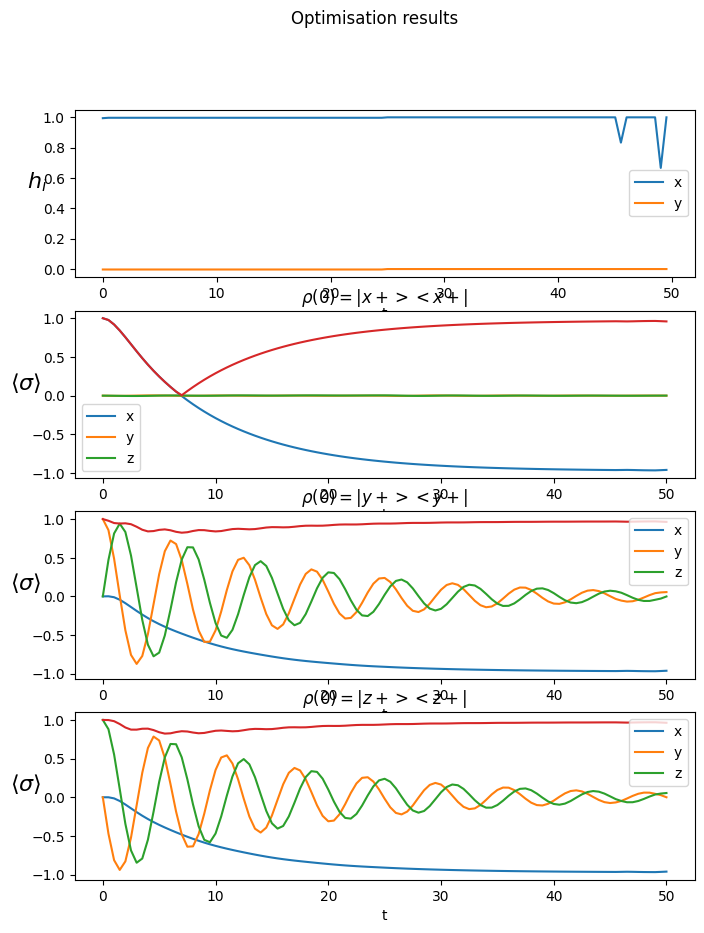

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1,figsize=(8,10)) 
fig.suptitle("Optimisation results")
fig.subplots_adjust(hspace=0.4)  # more vertical space between rows

field_labels = ["x","y","z"]
for i in range(0,num_params):
        axs[0].plot(t[:-1],optimization_result['x'][i::num_params],label=field_labels[i])
        axs[0].set_ylabel(r"$h_i$",rotation=0,fontsize=16)
        axs[0].set_xlabel("t")
        axs[0].legend()

basis_states=[op.SPIN_DM["x+"],op.SPIN_DM["y+"],op.SPIN_DM["z+"]] 
basis_labels=["|x+><x+|","|y+><y+|","|z+><z+|"]

for i,state in enumerate(basis_states):
        j=i+1
        # Input optimized controls into state_gradient to show dynamics of system under optimized fields
        optimized_dynamics = state_gradient(
                system=system,
                initial_state=np.array(state),
                target_derivative=target_derivative,
                process_tensors=[process_tensor_tebd],
                parameters=reshapedparas,
                num_steps=num_steps)

        dynamics = optimized_dynamics['dynamics']

        t, bloch_x =optimized_dynamics['dynamics'].expectations(op.sigma("x"))
        t, bloch_y = optimized_dynamics['dynamics'].expectations(op.sigma("y"))
        t, bloch_z = optimized_dynamics['dynamics'].expectations(op.sigma("z"))

        axs[j].plot(t,bloch_x,label='x')
        axs[j].plot(t,bloch_y,label='y')
        axs[j].plot(t,bloch_z,label='z')
        bloch_length = np.sqrt(bloch_x**2 +bloch_y**2 + bloch_z**2)
        axs[j].legend()
        axs[j].plot(t,bloch_length,label=r'$|\mathbf{\sigma}|$')
        axs[j].set_title(r"$\rho(0)={0}$".format(basis_labels[i]))
        axs[j].set_ylabel(r"$\langle \sigma \rangle$",rotation=0,fontsize=16)
        axs[j].set_xlabel("t")
